# Automated File Sorter and Data Preparation with Python

## Project Overview
This project automates the organization of incoming CSV and Excel files using Python.  
The script detects file types, creates folders if necessary, and sorts files into the correct directories.

After organizing the files, the project loads CSV data with pandas and performs a basic sales analysis and visualization.

## Tools Used
- Python
- pandas
- os
- shutil
- matplotlib

In [2]:
import os
import pandas as pd

path = "files"
os.makedirs(path, exist_ok=True)

# Create example CSV data
sales_data = pd.DataFrame({
    "date": ["2025-01-01","2025-01-02","2025-01-03","2025-01-04"],
    "product": ["Apple","Banana","Orange","Apple"],
    "quantity": [10,5,8,6],
    "price": [2.5,1.2,2.0,2.5]
})

sales_data.to_csv(os.path.join(path, "data_2024.csv"), index=False)

# Create example Excel data
customer_data = pd.DataFrame({
    "customer": ["John","Maria","David","Anna"],
    "purchase_amount": [120,85,60,140]
})

customer_data.to_excel(os.path.join(path, "customers.xlsx"), index=False)

In [3]:
path = "files"

csv_folder = os.path.join(path, "CSV Files")

## Files Before Sorting

In [4]:
print("Files after sorting:")
print(os.listdir(path))

Files after sorting:
['CSV Files', 'customers.xlsx', 'data_2024.csv', 'Excel Files']


## File Sorting Automation

The script below scans the folder and automatically moves files
into folders based on their extension.

In [5]:
import shutil

folders = {
    ".csv": "CSV Files",
    ".xlsx": "Excel Files"
}

# Create folders if they don't exist
for folder in folders.values():
    os.makedirs(os.path.join(path, folder), exist_ok=True)

# Sort files
for file in os.listdir(path):
    file_path = os.path.join(path, file)

    if not os.path.isfile(file_path):
        continue

    extension = os.path.splitext(file)[1]

    if extension in folders:
        destination = os.path.join(path, folders[extension], file)
        shutil.move(file_path, destination)

## Files After Sorting

In [6]:
print("Files after sorting:")
print(os.listdir(path))

Files after sorting:
['CSV Files', 'Excel Files']


## Load Data for Analysis

In [7]:
dataframes = []

for file in os.listdir(csv_folder):
    
    if file.endswith(".csv"):
        
        file_path = os.path.join(csv_folder, file)
        
        try:
            df = pd.read_csv(file_path)
            dataframes.append(df)
            
        except pd.errors.EmptyDataError:
            print(f"Skipping empty file: {file}")

Skipping empty file: data_2023.csv


## Combine All CSV Files

In [8]:
if len(dataframes) > 0:
    
    df = pd.concat(dataframes, ignore_index=True)

    print("Dataset Preview:")
    print(df.head())

else:
    
    print("No valid CSV files found.")

Dataset Preview:
         date product  quantity  price
0  2025-01-01   Apple        10    2.5
1  2025-01-02  Banana         5    1.2
2  2025-01-03  Orange         8    2.0
3  2025-01-04   Apple         6    2.5


In [9]:
# Calculate total sales
df["total_sales"] = df["quantity"] * df["price"]

print("Total revenue:", df["total_sales"].sum())

print("Sales by product:")
print(df.groupby("product")["total_sales"].sum())

Total revenue: 62.0
Sales by product:
product
Apple     40.0
Banana     6.0
Orange    16.0
Name: total_sales, dtype: float64


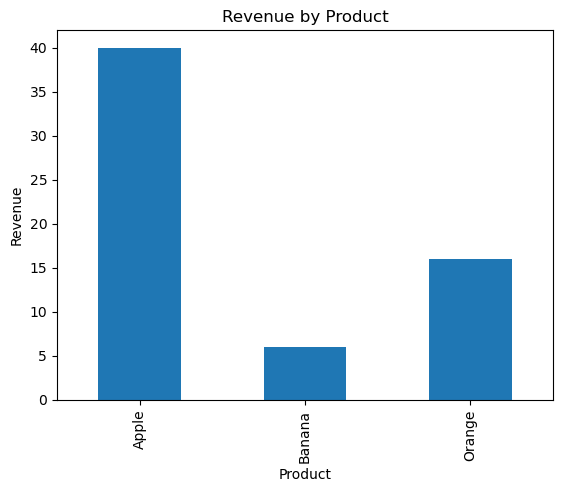

In [10]:
import matplotlib.pyplot as plt
sales_by_product = df.groupby("product")["total_sales"].sum()

sales_by_product.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

## Conclusion

This project demonstrates a simple automation workflow using Python.

The script automatically:

- Detects file types
- Creates folders if they do not exist
- Moves files into the correct folders
- Loads CSV files using pandas
- Performs basic sales analysis
- Generates a visualization of revenue by product

This type of automation can help reduce manual work and improve file organization and data preparation in business environments.